# Toy model: three spins on ten sites, with site-sized relaxations

`toy_four_site_relaxation` walked one spin over four sites. Here three spins
walk over ten sites at once. The number of spins is fixed at three, so there
are no birth or death moves; the sampler alternates the same two moves as
before:

- a **discrete** move, which puts one spin on a different, unoccupied site;
- a **continuous** move, which changes one component of one spin's offset
  $(\delta_\parallel, \delta_\perp)$ from the table value of its site.

**The size of the relaxation is set by the site.** Each component may move
by ±10% of its own table value. A site at (100, 100) kHz allows ±10 kHz in
each component; a site at (10, 10) allows ±1 kHz; a site at (100, 50) allows
±10 kHz in $A_\parallel$ and ±5 kHz in $A_\perp$. The prior is flat inside
the rectangle.

**Each site remembers its own offset.** When a spin leaves a site, that
site's offset stays where the local walk left it, and a spin that later
lands there, the same one or another, resumes from that value. A site that
has never been visited starts at its table value.

The data are simulated from three spins that each sit away from their
table value. The walk starts with the three spins on three other sites.

As in the four-site notebook, this is the package's site memory, switched
on with `site_memory=True`, and the site-sized rectangles come from its
`SiteScaledOffset` kernel.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RWMH,
    AnalyticCCE1,
    DiscreteLatticeWalk,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParameterBlock,
    Schedule,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per walker.  A walker is one of the three spins, followed through
# the run as it hops; ten sites are too many to tell apart by colour, so sites
# are labelled by number.  Start, target and recovered values are drawn in ink
# with distinct marker shapes.
WALKER_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]
C_RECOVERED = "#4a3aa7"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
C_SOFT = "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The lattice and the truth

Ten sites, given directly as $(A_\parallel, A_\perp)$ table values. They
span an order of magnitude, so the rectangles do too: the widest is 30 kHz
across and the narrowest 2 kHz. None of the rectangles overlap, so each of
the three true couplings can be reached from one site only.

In [2]:
FRACTION = 0.10                        # each component may move ±10%

CENTRES = np.array([
    (100.0, 100.0),    # 0
    (10.0, 10.0),      # 1
    (100.0, 50.0),     # 2
    (60.0, 80.0),      # 3
    (150.0, 60.0),     # 4
    (40.0, 30.0),      # 5
    (75.0, 120.0),     # 6
    (130.0, 110.0),    # 7
    (25.0, 60.0),      # 8
    (55.0, 45.0),      # 9
])
N_SITES, N_SPINS = len(CENTRES), 3
HALF = FRACTION * np.abs(CENTRES)      # (n_sites, 2) half-widths, kHz

# The spins the data are simulated from: site -> offset from its table value.
TRUE = {2: (5.0, 2.0), 3: (-4.0, 5.0), 7: (8.0, -6.0)}
START_SITES = (0, 5, 9)

# Real-space positions only decide which sites are neighbours.  The ten sit on
# a ring and the walk radius reaches all of them, so a spin can hop from any
# site to any unoccupied one.
_angle = np.linspace(0.0, 2.0 * np.pi, N_SITES, endpoint=False)
POSITIONS = np.column_stack([2.0 * np.cos(_angle), 2.0 * np.sin(_angle),
                             np.full(N_SITES, 2.0)])
HOP_RADIUS = 10.0

table = SiteTable(
    distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
    a_par=CENTRES[:, 0], a_perp=CENTRES[:, 1],
    isotope=np.array(["13C"] * N_SITES),
    gyro=np.full(N_SITES, gyromagnetic_ratio("13C")))

print(f"{'site':>4s} {'A_par':>7s} {'A_perp':>7s}   allowed range (kHz)")
for i in range(N_SITES):
    note = "   <- true spin, offset ({:+.0f}, {:+.0f})".format(*TRUE[i]) \
        if i in TRUE else ("   <- start" if i in START_SITES else "")
    print(f"{i:4d} {CENTRES[i, 0]:7.0f} {CENTRES[i, 1]:7.0f}   "
          f"±{HALF[i, 0]:4.1f} × ±{HALF[i, 1]:4.1f}{note}")

site   A_par  A_perp   allowed range (kHz)
   0     100     100   ±10.0 × ±10.0   <- start
   1      10      10   ± 1.0 × ± 1.0
   2     100      50   ±10.0 × ± 5.0   <- true spin, offset (+5, +2)
   3      60      80   ± 6.0 × ± 8.0   <- true spin, offset (-4, +5)
   4     150      60   ±15.0 × ± 6.0
   5      40      30   ± 4.0 × ± 3.0   <- start
   6      75     120   ± 7.5 × ±12.0
   7     130     110   ±13.0 × ±11.0   <- true spin, offset (+8, -6)
   8      25      60   ± 2.5 × ± 6.0
   9      55      45   ± 5.5 × ± 4.5   <- start


## 2. The sampler

No decoherence envelope, and CPMG-4, for the reasons given in the four-site
notebook: at 16 pulses the likelihood is too sharply peaked for one chain to
cross between sites. Here that failure is concrete. At 16 pulses, four seeds
out of four ended with a spin on site 4 where site 7 belongs; at 4 pulses,
four out of four recovered all three sites.

Both moves are the package's `RWMH`, as before, now with several spins:

- the site walk moves one spin, and site memory gives that spin the offset
  its new site remembers;
- the offset walk picks one spin and one component, and `SiteScaledOffset`
  proposes a step reflected at ±10% of that site's table value.

The largest single step is 1 kHz, or the half-width of the rectangle where
that is smaller.

In [3]:
DATA_NOISE, LIK_SIGMA = 0.002, 0.02
N_PULSES, B_Z = 4, 311.0
tau = np.linspace(3.2e-5, 8e-3, 250)   # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=N_PULSES, b_z=B_Z)])


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


model = AnalyticCCE1(NoEnvelope())


def make_state(sites, offsets=None):
    """Three spins on ``sites``, each offset from its table value."""
    state = State.from_sites(
        tuple(sites), n_sites=N_SITES, n_exp=1,
        # A State must carry a decay constant; NoEnvelope never reads it.
        lam=np.ones((1, 1)), n_stretch=np.ones((1, 1)),
        sigma=np.full((1, 1), LIK_SIGMA), k_max=N_SPINS, site_memory=True)
    if offsets is not None:
        for slot, (d_par, d_perp) in enumerate(offsets):
            state.set_offset(0, slot, 0, d_par)
            state.set_offset(0, slot, 1, d_perp)
    return state

## 3. The run

One site move, then five offset moves, repeated, through the package's
hybrid driver.

In [4]:
N_STEPS, N_BURN = 15000, 3000
SITE_STEPS, OFFSET_STEPS = 1, 5
STEP_KHZ = 1.0

truth = make_state(list(TRUE), list(TRUE.values()))
data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

schedule = Schedule([
    Step(RWMH(ParameterBlock("sites"),
              DiscreteLatticeWalk(NeighborIndex(POSITIONS, HOP_RADIUS))),
         SITE_STEPS),
    Step(RWMH(ParameterBlock("offsets"), SiteScaledOffset(
        STEP_KHZ, table, fraction_par=FRACTION, fraction_perp=FRACTION,
        prior="flat")), OFFSET_STEPS),
])
initial = make_state(START_SITES)
trace = Trace(n_sites=N_SITES, k_max=N_SPINS, n_exp=1)
HybridDriver(schedule).run(initial, target, np.random.default_rng(0), N_STEPS,
                           trace=trace)

# The trace records the state after each step; put the start at the front.
# Every array below is (step, walker).
site = np.vstack([initial.site_idx[0], trace.site_idx])
d_par = np.vstack([initial.dA_par[0], trace.dA_par])
d_perp = np.vstack([initial.dA_perp[0], trace.dA_perp])
a_par = CENTRES[site, 0] + d_par
a_perp = CENTRES[site, 1] + d_perp
log_like = np.concatenate([target.log_prob(initial), np.asarray(trace.log_prob)])
steps = np.arange(len(site))

hop_steps = np.flatnonzero((np.diff(site, axis=0) != 0).any(axis=1))
print(f"site hops: {hop_steps.size} in {N_STEPS} steps "
      f"({(hop_steps >= N_BURN).sum()} after burn-in)")
print(f"log-likelihood: start {log_like[0]:.1f}, truth "
      f"{target.log_prob(truth)[0]:.2f}")

site hops: 6 in 15000 steps (0 after burn-in)
log-likelihood: start -813.9, truth -1.29


## 4. What was recovered

The recovered configuration is the highest-likelihood sample after burn-in:
three sites and an offset at each.

In [5]:
best = N_BURN + int(np.argmax(log_like[N_BURN:]))
recovered = make_state(site[best], list(zip(d_par[best], d_perp[best], strict=True)))

true_sites = sorted(TRUE)
found_sites = sorted(int(s) for s in site[best])
print(f"true sites     : {true_sites}")
print(f"recovered sites: {found_sites}   "
      f"log-likelihood {log_like[best]:.2f}\n")
print(f"{'site':>4s}  {'target (kHz)':>16s}  {'recovered (kHz)':>18s}  "
      f"{'error (kHz)':>14s}")
for walker in np.argsort(site[best]):
    s = int(site[best, walker])
    rec = (a_par[best, walker], a_perp[best, walker])
    if s in TRUE:
        tgt = CENTRES[s] + np.array(TRUE[s])
        print(f"{s:4d}  ({tgt[0]:6.2f}, {tgt[1]:6.2f})  "
              f"({rec[0]:7.2f}, {rec[1]:7.2f})  "
              f"({rec[0] - tgt[0]:+5.2f}, {rec[1] - tgt[1]:+5.2f})")
    else:
        print(f"{s:4d}  {'not a true site':>16s}  ({rec[0]:7.2f}, {rec[1]:7.2f})")

kept = site[N_BURN:]
occupied = np.array([(kept == i).any(axis=1).mean() for i in range(N_SITES)])
print("\nshare of steps after burn-in each site is occupied:")
print("  " + ", ".join(f"site {i}: {occupied[i]:.0%}" for i in range(N_SITES)))

true sites     : [2, 3, 7]
recovered sites: [2, 3, 7]   log-likelihood -1.39

site      target (kHz)     recovered (kHz)     error (kHz)
   2  (105.00,  52.00)  ( 105.72,   51.65)  (+0.72, -0.35)
   3  ( 56.00,  85.00)  (  56.01,   85.42)  (+0.01, +0.42)
   7  (138.00, 104.00)  ( 138.22,  103.53)  (+0.22, -0.47)

share of steps after burn-in each site is occupied:
  site 0: 0%, site 1: 0%, site 2: 100%, site 3: 100%, site 4: 0%, site 5: 0%, site 6: 0%, site 7: 100%, site 8: 0%, site 9: 0%


## 5. The walk in coupling space

Every site's rectangle of allowed couplings, drawn to scale, with the three
walkers' samples and a line for each hop. Section 7 looks inside each site.

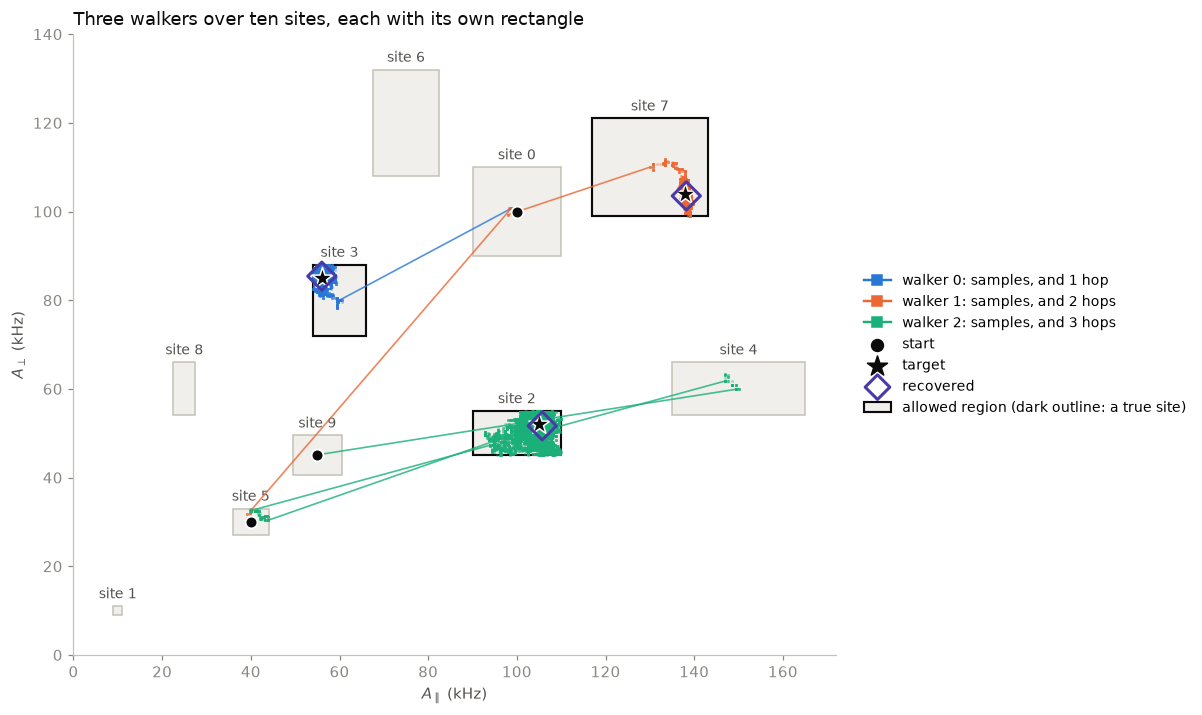

In [6]:
def site_markers(ax, i, relative=False):
    """Start, target and recovered markers for site ``i``, if it has them."""
    def place(point):
        if not relative:
            return point
        return 100.0 * (np.asarray(point) - CENTRES[i]) / CENTRES[i]

    if i in START_SITES:
        ax.scatter(*place(CENTRES[i]), s=60, marker="o", color=C_INK,
                   edgecolor="white", linewidths=1.2, zorder=6)
    if i in TRUE:
        ax.scatter(*place(CENTRES[i] + np.array(TRUE[i])), s=210, marker="*",
                   color=C_INK, edgecolor="white", linewidths=1.0, zorder=7)
    for walker in np.flatnonzero(site[best] == i):
        ax.scatter(*place((a_par[best, walker], a_perp[best, walker])), s=170,
                   marker="D", facecolor="none", edgecolor=C_RECOVERED,
                   linewidths=2.0, zorder=8)


fig, ax = plt.subplots(figsize=(11.0, 6.6))
for i in range(N_SITES):
    is_true = i in TRUE
    ax.add_patch(Rectangle(
        CENTRES[i] - HALF[i], 2 * HALF[i, 0], 2 * HALF[i, 1],
        facecolor=C_SOFT, edgecolor=C_INK if is_true else C_AXIS,
        lw=1.4 if is_true else 1.0, zorder=0))
    ax.annotate(f"site {i}", (CENTRES[i, 0], CENTRES[i, 1] + HALF[i, 1]),
                xytext=(0, 3), textcoords="offset points", ha="center",
                va="bottom", fontsize=9, color="#52514e")
    site_markers(ax, i)

for walker in range(N_SPINS):
    ax.scatter(a_par[:, walker], a_perp[:, walker], s=4,
               color=WALKER_COLOURS[walker], alpha=0.35, linewidths=0, zorder=3)
    hops = np.flatnonzero(np.diff(site[:, walker]) != 0)
    for h in hops:
        ax.plot(a_par[h: h + 2, walker], a_perp[h: h + 2, walker],
                color=WALKER_COLOURS[walker], lw=1.1, alpha=0.8, zorder=4)
    ax.plot([], [], color=WALKER_COLOURS[walker], lw=1.6, marker="s", ms=6,
            label=f"walker {walker}: samples, and {hops.size} "
                  f"hop{'s' if hops.size != 1 else ''}")

ax.scatter([], [], s=60, marker="o", color=C_INK, label="start")
ax.scatter([], [], s=190, marker="*", color=C_INK, label="target")
ax.scatter([], [], s=130, marker="D", facecolor="none", edgecolor=C_RECOVERED,
           linewidths=2.0, label="recovered")
ax.add_patch(Rectangle((0, 0), 0, 0, facecolor=C_SOFT, edgecolor=C_INK, lw=1.4,
                       label="allowed region (dark outline: a true site)"))
ax.set_aspect("equal")
ax.set_xlim(0, 172)
ax.set_ylim(0, 140)
ax.set_xlabel(r"$A_\parallel$ (kHz)")
ax.set_ylabel(r"$A_\perp$ (kHz)")
ax.set_title("Three walkers over ten sites, each with its own rectangle",
             loc="left", color=C_INK)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.tight_layout()
plt.show()

## 6. The walk across sites

Which site each walker is on at each step, with the misfit underneath. The
hops all happen early, so the opening steps are shown beside the whole run.
The shaded rows are the three true sites.

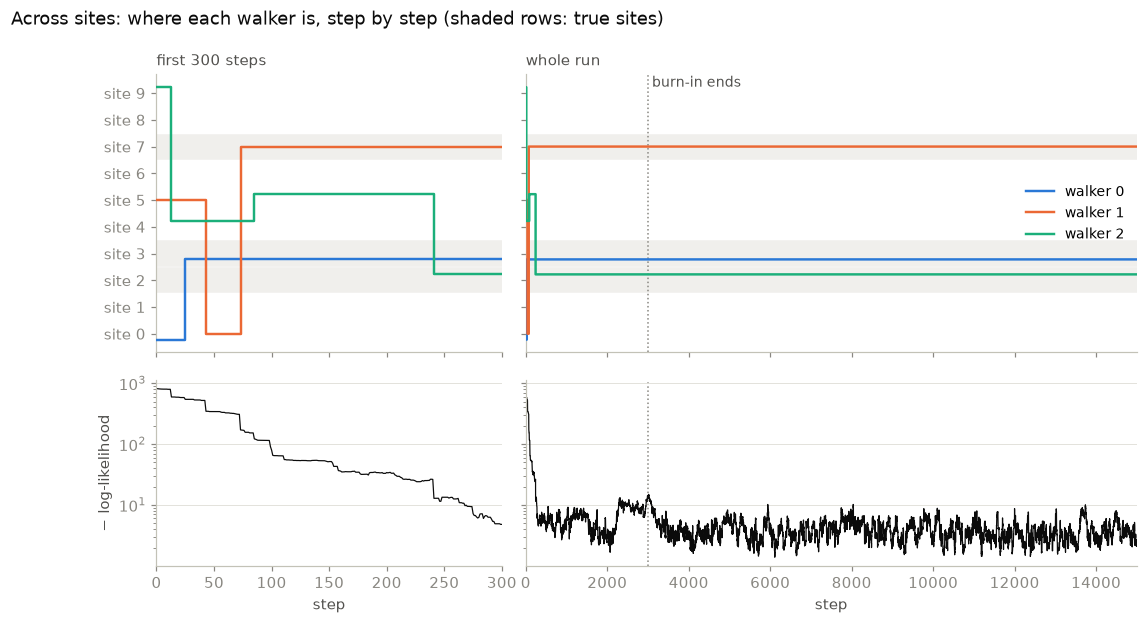

In [7]:
OPENING = 300

fig, axes = plt.subplots(
    2, 2, figsize=(11.5, 5.8), sharex="col", sharey="row",
    gridspec_kw={"width_ratios": [1.3, 2.3], "height_ratios": [1.5, 1],
                 "hspace": 0.12, "wspace": 0.05})
for column, last in enumerate((OPENING, len(steps) - 1)):
    top, bottom = axes[0, column], axes[1, column]
    show = steps <= last
    for s in TRUE:
        top.axhspan(s - 0.45, s + 0.45, color=C_SOFT, zorder=0)
    if last > N_BURN:
        for ax in (top, bottom):
            ax.axvline(N_BURN, color=C_MUTED, lw=1.0, ls=":", zorder=1)
        top.text(N_BURN, N_SITES - 0.35, " burn-in ends", fontsize=9,
                 color="#52514e", va="top")
    for walker in range(N_SPINS):
        # Walkers on the same row would hide one another; nudge them apart.
        nudge = 0.22 * (walker - 1)
        top.plot(steps[show], site[show, walker] + nudge, drawstyle="steps-post",
                 color=WALKER_COLOURS[walker], lw=1.6, zorder=3,
                 label=f"walker {walker}")
    bottom.plot(steps[show], -log_like[show], color=C_INK, lw=0.8, zorder=2)
    bottom.set_yscale("log")
    bottom.grid(axis="y")
    bottom.set_xlabel("step")
    for ax in (top, bottom):
        ax.set_xlim(0, last)
    top.set_title(f"first {OPENING} steps" if column == 0 else "whole run",
                  loc="left", color="#52514e", fontsize=10)
axes[0, 0].set_yticks(range(N_SITES), [f"site {i}" for i in range(N_SITES)])
axes[0, 0].set_ylim(-0.7, N_SITES - 0.3)
axes[1, 0].set_ylabel("− log-likelihood")
axes[0, 1].legend(loc="center right", fontsize=9)
fig.suptitle("Across sites: where each walker is, step by step "
             "(shaded rows: true sites)", x=0.01, ha="left", color=C_INK)
plt.show()

## 7. The walk within each site

One panel per site. The rectangles differ in size by a factor of fifteen, so
the offset is drawn as a percentage of the table value, which makes every
rectangle the same ±10% square. The size in kHz is in each panel's title.
Grey points are from burn-in; coloured points are kept samples, coloured by
walker.

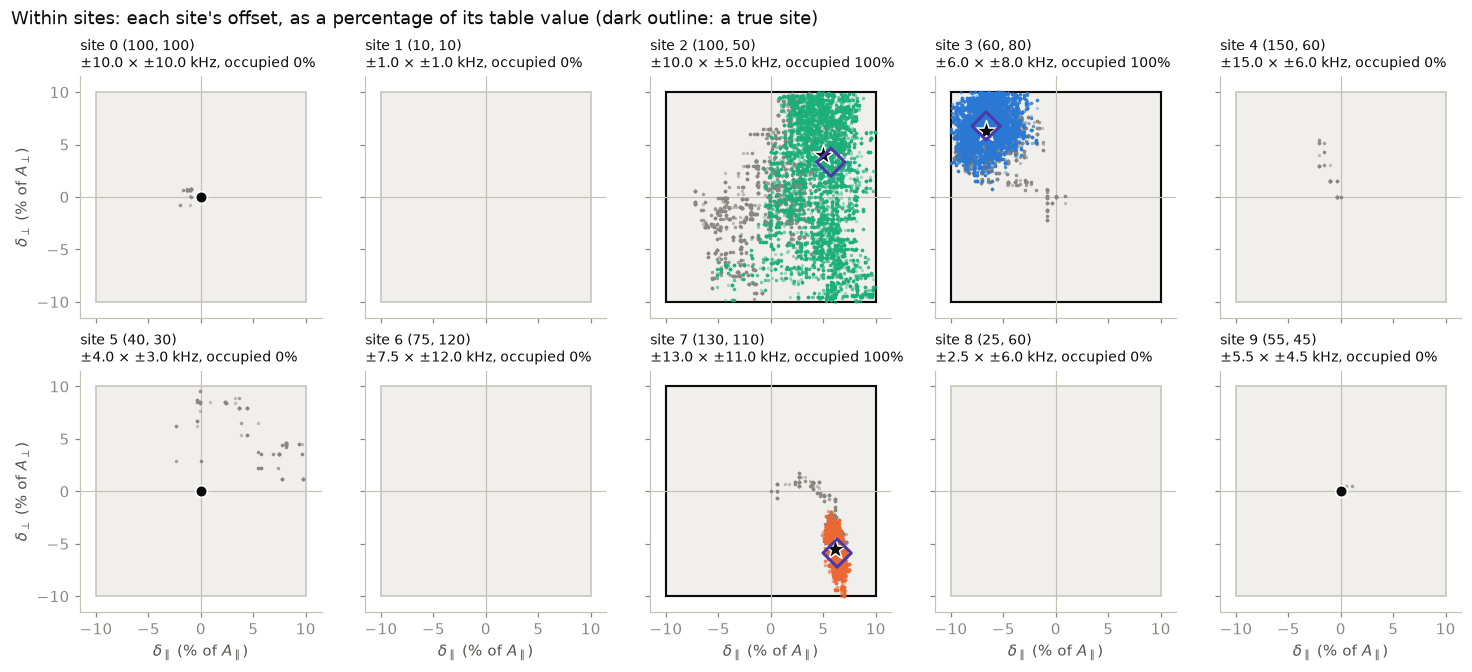

In [8]:
is_kept = steps >= N_BURN

fig, axes = plt.subplots(2, 5, figsize=(13.5, 6.0), sharex=True, sharey=True,
                         layout="constrained")
for i, ax in enumerate(axes.flat):
    ax.add_patch(Rectangle((-10, -10), 20, 20, facecolor=C_SOFT,
                           edgecolor=C_INK if i in TRUE else C_AXIS,
                           lw=1.4 if i in TRUE else 1.0, zorder=0))
    ax.axhline(0.0, color=C_AXIS, lw=0.8, zorder=1)
    ax.axvline(0.0, color=C_AXIS, lw=0.8, zorder=1)
    for walker in range(N_SPINS):
        here = site[:, walker] == i
        x = 100.0 * d_par[:, walker] / CENTRES[i, 0]
        y = 100.0 * d_perp[:, walker] / CENTRES[i, 1]
        ax.scatter(x[here & ~is_kept], y[here & ~is_kept], s=5, color=C_MUTED,
                   alpha=0.5, linewidths=0, zorder=2)
        ax.scatter(x[here & is_kept], y[here & is_kept], s=5,
                   color=WALKER_COLOURS[walker], alpha=0.35, linewidths=0,
                   zorder=3)
    site_markers(ax, i, relative=True)
    ax.set_xlim(-11.5, 11.5)
    ax.set_ylim(-11.5, 11.5)
    ax.set_aspect("equal")
    ax.set_title(f"site {i} ({CENTRES[i, 0]:.0f}, {CENTRES[i, 1]:.0f})\n"
                 f"±{HALF[i, 0]:.1f} × ±{HALF[i, 1]:.1f} kHz, "
                 f"occupied {occupied[i]:.0%}",
                 loc="left", color=C_INK, fontsize=9)
for ax in axes[1]:
    ax.set_xlabel(r"$\delta_\parallel$ (% of $A_\parallel$)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\delta_\perp$ (% of $A_\perp$)")
fig.suptitle("Within sites: each site's offset, as a percentage of its table "
             "value (dark outline: a true site)", x=0.01, ha="left",
             color=C_INK)
plt.show()

## 8. The signals

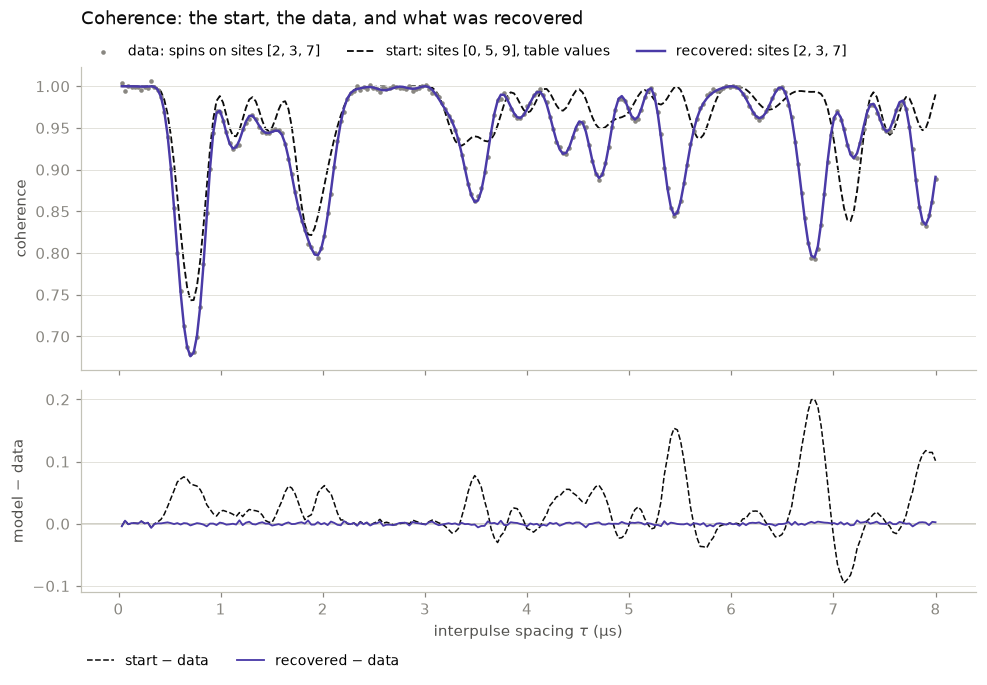

rms residual, start    : 0.0510
rms residual, recovered: 0.0021   (data noise 0.002)


In [9]:
sig_initial = simulate_coherence(initial, blank, table, model)
sig_recovered = simulate_coherence(recovered, blank, table, model)
measured = data.data_all
tau_us = tau * 1e3

_, (top, bottom) = plt.subplots(
    2, 1, figsize=(10.5, 6.2), sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
top.scatter(tau_us, measured, s=9, color=C_MUTED, linewidths=0, zorder=2,
            label=f"data: spins on sites {true_sites}")
top.plot(tau_us, sig_initial, color=C_INK, lw=1.2, ls="--", zorder=1,
         label=f"start: sites {sorted(START_SITES)}, table values")
top.plot(tau_us, sig_recovered, color=C_RECOVERED, lw=1.6, zorder=3,
         label=f"recovered: sites {found_sites}")
top.set_ylabel("coherence")
top.set_title("Coherence: the start, the data, and what was recovered",
              loc="left", color=C_INK, pad=28)
top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3, fontsize=9,
           borderaxespad=0.2)
top.grid(axis="y")

bottom.axhline(0.0, color=C_AXIS, lw=1.0, zorder=1)
bottom.plot(tau_us, sig_initial - measured, color=C_INK, lw=1.0, ls="--",
            zorder=2, label="start − data")
bottom.plot(tau_us, sig_recovered - measured, color=C_RECOVERED, lw=1.2,
            zorder=3, label="recovered − data")
bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
bottom.set_ylabel("model − data")
bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=2,
              fontsize=9, borderaxespad=0.0)
bottom.grid(axis="y")
plt.show()

rms_initial = np.sqrt(np.mean((sig_initial - measured) ** 2))
rms_recovered = np.sqrt(np.mean((sig_recovered - measured) ** 2))
print(f"rms residual, start    : {rms_initial:.4f}")
print(f"rms residual, recovered: {rms_recovered:.4f}   (data noise {DATA_NOISE})")

## 9. What to read off

- **The sites are recovered, and early.** All six hops happen in the first
  240 steps. After that each walker is on a true site, every other site
  fits far worse, and no hop is accepted again. With rectangles that do not
  overlap, the walk across sites is short.
- **How well a coupling is pinned down depends on the site, not on the size
  of its rectangle.** Sites 3 and 7 are held to a small part of their
  rectangles. Site 2 is not: its samples spread over most of the ±10% square
  and press against its edges, so for that spin the data say little more
  than the prior does, and its recovered coupling is the furthest from the
  target, 0.7 kHz out in $A_\parallel$.
- **Abandoned sites keep what they were left with.** Sites 0, 4, 5 and 9
  were each occupied for part of the first 240 steps, and their remembered
  offsets are wherever the local walk had got to when the spin left. Sites
  1, 6 and 8 were never visited and are still at their table values.
- **Which walker ends on which site is arbitrary.** The three spins are
  interchangeable; only the set of occupied sites means anything.